# Szeregi czasowe i prognozowanie — od dekompozycji do walidacji bez przecieku

Notebook krok po kroku: co odróżnia szereg czasowy od "zwykłych" danych,
jak sprawdzić jego właściwości przed wyborem modelu, klasyczne modele
(wygładzanie wykładnicze, SARIMA) i podejście feature-based (lagi +
sklearn), z naciskiem na coś, co łatwo pominąć: **poprawną walidację**.

Powracający motyw z poprzednich notebooków: `train_test_split` z
losowym mieszaniem (sklearn) i k-fold cross-validation są dla szeregów
czasowych formą data leakage — model "uczy się z przyszłości", żeby
przewidzieć przeszłość. Sekcja 7 pokazuje to na konkretnym przykładzie.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid")

## 1. Dane przykładowe — syntetyczna sprzedaż miesięczna

Trend rosnący + sezonowość roczna (szczyt w grudniu, spadek latem) + szum —
typowy kształt danych sprzedażowych, żeby dalsze sekcje (dekompozycja,
ACF/PACF, ARIMA) miały co wykryć.

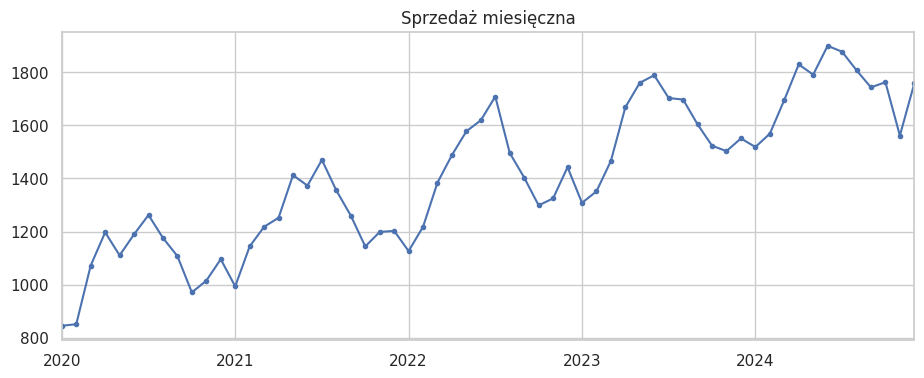

In [2]:
liczba_miesiecy = 60   # 5 lat danych miesięcznych
daty = pd.date_range("2020-01-01", periods=liczba_miesiecy, freq="MS")

trend = np.linspace(1000, 1800, liczba_miesiecy)
sezonowosc = 200 * np.sin(2 * np.pi * (daty.month - 3) / 12) + 100 * (daty.month == 12)
szum = rng.normal(0, 60, liczba_miesiecy)

sprzedaz = pd.Series(trend + sezonowosc + szum, index=daty, name="sprzedaz")

fig, ax = plt.subplots(figsize=(11, 4))
sprzedaz.plot(ax=ax, marker="o", markersize=3)
ax.set_title("Sprzedaż miesięczna")
plt.show()

`freq="MS"` (Month Start) w `date_range` i **regularny, jawnie zdefiniowany
indeks czasowy** to fundament wszystkiego poniżej — modele szeregów
czasowych w `statsmodels` zakładają stałą częstotliwość. Prawdziwe dane
(np. z SQL Server) zwykle trzeba do tego doprowadzić:

In [3]:
# typowy krok porządkowy na realnych danych: agregacja transakcji do regularnej siatki miesięcy
# (na potrzeby demo: symulacja pojedynczych transakcji, potem ponowna agregacja do miesięcy)
transakcje = pd.DataFrame({
    "data": pd.to_datetime(rng.choice(pd.date_range("2020-01-01", "2024-12-31"), 5000)),
    "kwota": rng.gamma(2, 150, 5000),
})

sprzedaz_z_transakcji = (
    transakcje.set_index("data")["kwota"]
    .resample("MS")   # agregacja do siatki miesięcznej — WYMAGANE, żeby mieć regularny szereg
    .sum()
)
sprzedaz_z_transakcji.head()

data
2020-01-01    18973.907508
2020-02-01    26098.282591
2020-03-01    28691.311707
2020-04-01    23919.717348
2020-05-01    19879.677165
Freq: MS, Name: kwota, dtype: float64

## 2. Dekompozycja — trend, sezonowość, reszty

`seasonal_decompose` rozbija szereg na trzy składowe. Wybór modelu:
- **addytywny** (`model="additive"`) — amplituda sezonowości STAŁA w czasie (np. zawsze ±200)
- **multiplikatywny** (`model="multiplicative"`) — amplituda ROŚNIE razem z poziomem szeregu (sezonowość jako % wartości, nie stała liczba)

Nasze dane mają stałą amplitudę sezonowości niezależnie od poziomu trendu
→ addytywny jest właściwym wyborem.

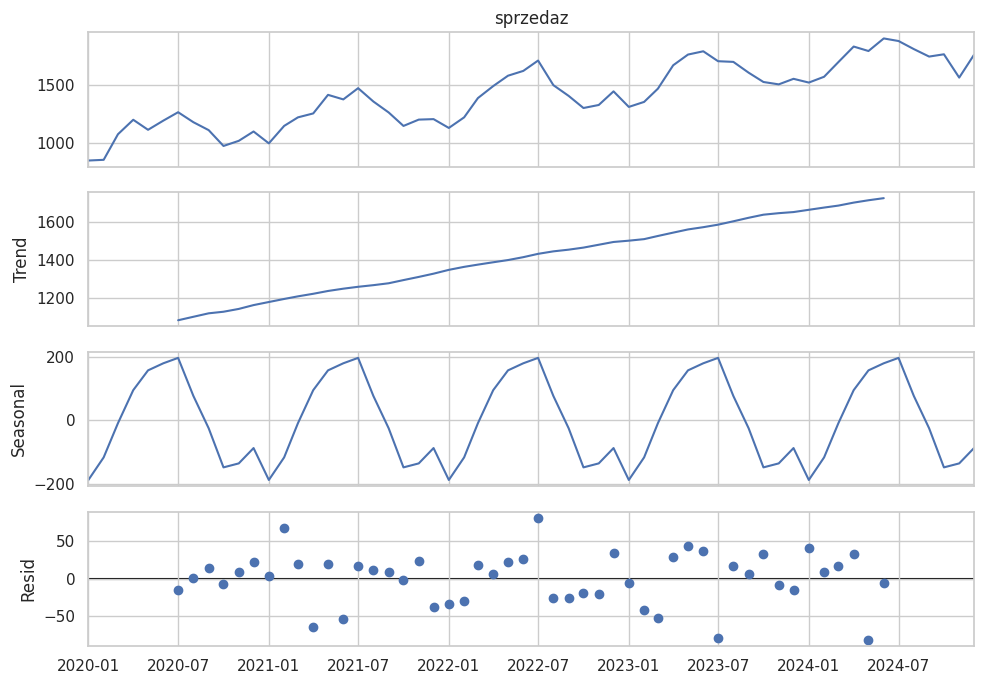

In [4]:
dekompozycja = seasonal_decompose(sprzedaz, model="additive", period=12)   # period=12 -> sezonowość roczna w danych miesięcznych

fig = dekompozycja.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

`period` **musi** odpowiadać rzeczywistej długości cyklu sezonowego w
jednostkach Twoich danych: `12` dla rocznej sezonowości w danych
miesięcznych, `7` dla tygodniowej w danych dziennych, `4` dla rocznej w
danych kwartalnych. Błędny `period` daje dekompozycję, która wygląda
"jakoś", ale nic sensownego nie pokazuje.

## 3. Stacjonarność — dlaczego to sprawdzamy i test ADF

Wiele klasycznych modeli (ARIMA) zakłada **stacjonarność**: stała średnia,
stała wariancja, brak trendu w czasie. Nasz szereg z rosnącym trendem
wyraźnie stacjonarny nie jest — sprawdzamy to formalnie testem
Augmented Dickey-Fuller (ADF).

H0 testu ADF: szereg NIE jest stacjonarny (ma pierwiastek jednostkowy).
p-value < 0.05 → odrzucamy H0 → szereg stacjonarny.

In [5]:
wynik_adf = adfuller(sprzedaz)
print(f"Statystyka ADF: {wynik_adf[0]:.3f}")
print(f"p-value: {wynik_adf[1]:.4f}")
print("Wniosek:", "stacjonarny" if wynik_adf[1] < 0.05 else "NIEstacjonarny (oczekiwane — mamy trend)")

Statystyka ADF: -0.835
p-value: 0.8087
Wniosek: NIEstacjonarny (oczekiwane — mamy trend)


/tmp/ipykernel_132/1595177319.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  wynik_adf = adfuller(sprzedaz)


p-value po różnicowaniu: 0.0000
Wniosek: stacjonarny


/tmp/ipykernel_132/3602377044.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  wynik_adf_po_roznicowaniu = adfuller(sprzedaz_zroznicowana)


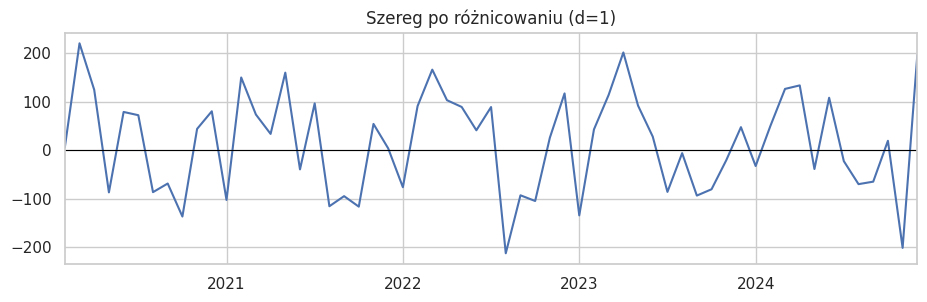

In [6]:
# różnicowanie (differencing) — standardowy sposób uzyskania stacjonarności: modelujemy PRZYROSTY, nie poziom
sprzedaz_zroznicowana = sprzedaz.diff().dropna()

wynik_adf_po_roznicowaniu = adfuller(sprzedaz_zroznicowana)
print(f"p-value po różnicowaniu: {wynik_adf_po_roznicowaniu[1]:.4f}")
print("Wniosek:", "stacjonarny" if wynik_adf_po_roznicowaniu[1] < 0.05 else "nadal NIEstacjonarny")

fig, ax = plt.subplots(figsize=(11, 3))
sprzedaz_zroznicowana.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Szereg po różnicowaniu (d=1)")
plt.show()

Ten sam parametr (rząd różnicowania) to **`d`** w ARIMA(p,d,q) — sekcja 6.
Jeśli jedno różnicowanie nie wystarcza (rzadkie w praktyce), różnicuje się
ponownie (`d=2`), ale każde kolejne różnicowanie utrudnia interpretację i
zwiększa wariancję prognozy — w praktyce `d=0`, `1` lub `2` wyczerpuje
niemal wszystkie przypadki.

## 4. ACF / PACF — dobór rzędu modelu

- **ACF** (autokorelacja) — korelacja szeregu z jego opóźnioną (lag) wersją,
  włączając efekty pośrednie (przez wcześniejsze opóźnienia).
- **PACF** (autokorelacja cząstkowa) — to samo, ale "oczyszczone" z efektów
  pośrednich — pokazuje bezpośredni wpływ konkretnego opóźnienia.

Praktyczna zasada doboru rzędu ARIMA z wykresów: **PACF** urywa się ostro
po opóźnieniu `p` → sugeruje składową AR(p); **ACF** urywa się ostro po
opóźnieniu `q` → sugeruje składową MA(q). W praktyce i tak zwykle
weryfikuje się kilka kombinacji przez AIC (sekcja 6), ale wykresy dają
rozsądny punkt startowy zamiast przeszukiwania na ślepo.

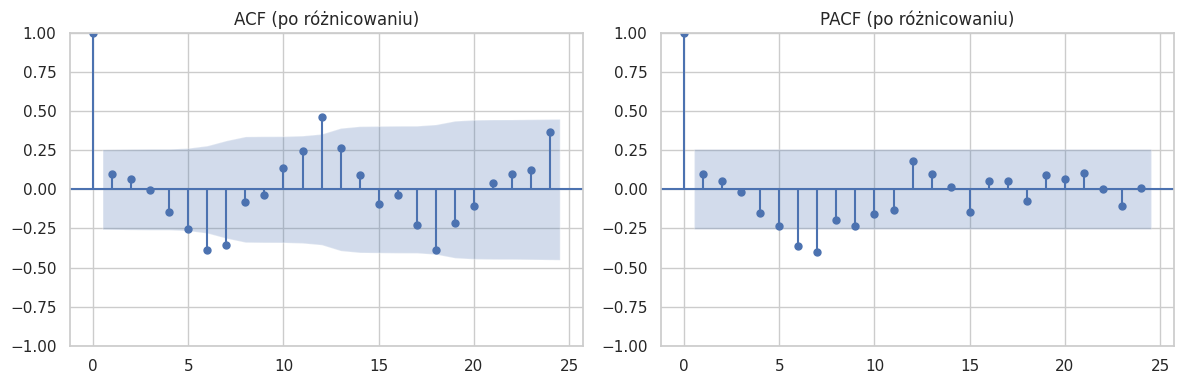

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(sprzedaz_zroznicowana, ax=axes[0], lags=24)
axes[0].set_title("ACF (po różnicowaniu)")
plot_pacf(sprzedaz_zroznicowana, ax=axes[1], lags=24)
axes[1].set_title("PACF (po różnicowaniu)")
plt.tight_layout()
plt.show()

Widoczny regularny wzorzec co 12 opóźnień to **sezonowość roczna**, którą
zwykły ARIMA (bez składowej sezonowej) modeluje słabo — stąd SARIMA
(sekcja 6b), gdzie sezonowość dostaje własne parametry `(P,D,Q,s)`.

## 5. Baseline — zawsze najpierw punkt odniesienia

Zanim sięgniesz po ARIMA/ML — policz prognozę "naiwną": ostatnia znana
wartość (albo, lepiej dla danych sezonowych, wartość sprzed roku).
**Każdy** bardziej złożony model musi ją pobić, inaczej nie ma sensu
biznesowego (nawiązanie do baseline'u z notebooka o sklearn — ta sama
zasada, tu w wersji dla szeregów czasowych).

In [8]:
train = sprzedaz[:-12]     # ostatnie 12 miesięcy jako zbiór testowy
test = sprzedaz[-12:]

prognoza_naiwna_sezonowa = train[-12:].values   # "tyle co rok temu w tym samym miesiącu"

mae_naiwny = mean_absolute_error(test, prognoza_naiwna_sezonowa)
print(f"MAE baseline (sezonowa naiwna): {mae_naiwny:.1f}")

MAE baseline (sezonowa naiwna): 157.4


## 6. Modele klasyczne

### a) Wygładzanie wykładnicze (Holt-Winters)

Dobry, prosty punkt startowy przy wyraźnym trendzie i sezonowości — mniej
parametrów do stroienia niż SARIMA, często zaskakująco konkurencyjny.

In [9]:
model_hw = ExponentialSmoothing(
    train,
    trend="add",          # WYMAGANE dla danych z trendem — "add" (liniowy) / "mul" / None
    seasonal="add",        # WYMAGANE dla danych sezonowych — jak przy dekompozycji: add/mul
    seasonal_periods=12,   # WYMAGANE gdy seasonal != None — długość cyklu (patrz sekcja 2)
).fit()

prognoza_hw = model_hw.forecast(12)

mae_hw = mean_absolute_error(test, prognoza_hw)
print(f"MAE Holt-Winters: {mae_hw:.1f}  (baseline: {mae_naiwny:.1f})")

MAE Holt-Winters: 45.7  (baseline: 157.4)


### b) SARIMA — ARIMA z jawną składową sezonową

`SARIMAX(p,d,q)(P,D,Q,s)` — pierwsza trójka to zwykły ARIMA (z sekcji 3-4),
druga trójka to te same parametry, ale dla składowej **sezonowej**, `s` to
długość cyklu. Dobór rzędów przez małe przeszukanie po AIC (niższy =
lepiej) zamiast zgadywania — typowa praktyka, gdy ACF/PACF nie dają
jednoznacznej odpowiedzi.

In [10]:
najlepszy_aic = np.inf
najlepsze_parametry = None

for p in range(0, 3):
    for d in [1]:              # ustalone na podstawie sekcji 3 (jedno różnicowanie wystarczyło)
        for q in range(0, 3):
            try:
                model_probny = SARIMAX(
                    train, order=(p, d, q), seasonal_order=(1, 1, 1, 12),
                    enforce_stationarity=False, enforce_invertibility=False,
                ).fit(disp=False)
                if model_probny.aic < najlepszy_aic:
                    najlepszy_aic = model_probny.aic
                    najlepsze_parametry = (p, d, q)
            except Exception:
                continue   # niektóre kombinacje mogą się nie zbiec — pomijamy, nie przerywamy przeszukiwania

print(f"Najlepsze (p,d,q): {najlepsze_parametry}, AIC={najlepszy_aic:.1f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Najlepsze (p,d,q): (0, 1, 2), AIC=228.4


Jeśli powyżej pojawiły się ostrzeżenia `EstimationWarning`/`ConvergenceWarning`
— to nie błąd w kodzie, tylko realny sygnał: przy 48 miesiącach danych i
cyklu sezonowym 12 mamy zaledwie ~4 pełne cykle roczne, za mało, żeby
solidnie oszacować sezonowe parametry SARIMA. W praktyce dla wiarygodnej
sezonowej SARIMA warto mieć **co najmniej 4-5 pełnych cykli** (tu: 4-5 lat
danych miesięcznych) — przy mniejszej historii Holt-Winters (mniej
parametrów do oszacowania) bywa stabilniejszym wyborem, co zresztą widać
w wyniku MAE poniżej.

In [11]:
model_sarima = SARIMAX(
    train,
    order=najlepsze_parametry,
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

prognoza_sarima = model_sarima.get_forecast(12)
wartosci_prognozy = prognoza_sarima.predicted_mean
przedzial_ufnosci = prognoza_sarima.conf_int(alpha=0.05)   # 95% przedział ufności

mae_sarima = mean_absolute_error(test, wartosci_prognozy)
print(f"MAE SARIMA: {mae_sarima:.1f}  (baseline: {mae_naiwny:.1f}, Holt-Winters: {mae_hw:.1f})")

MAE SARIMA: 50.5  (baseline: 157.4, Holt-Winters: 45.7)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


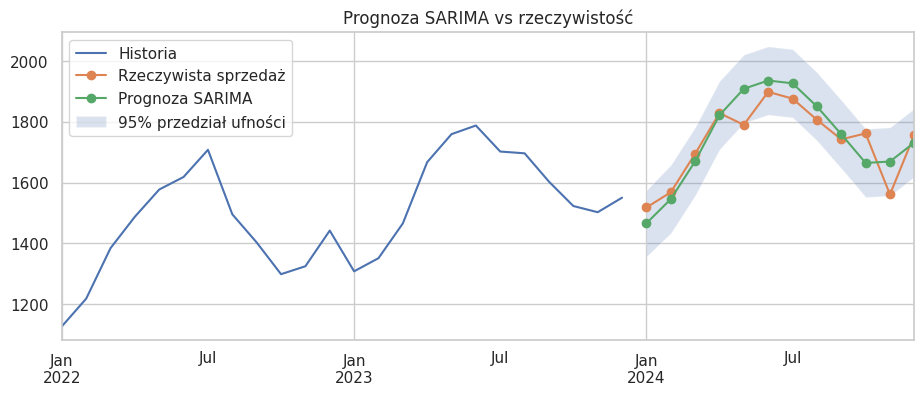

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
train[-24:].plot(ax=ax, label="Historia")
test.plot(ax=ax, label="Rzeczywista sprzedaż", marker="o")
wartosci_prognozy.plot(ax=ax, label="Prognoza SARIMA", marker="o")
ax.fill_between(przedzial_ufnosci.index, przedzial_ufnosci.iloc[:, 0], przedzial_ufnosci.iloc[:, 1],
                 alpha=0.2, label="95% przedział ufności")
ax.legend()
ax.set_title("Prognoza SARIMA vs rzeczywistość")
plt.show()

**Przedział ufności to nie dodatek kosmetyczny** — prognoza punktowa
("1650") bez przedziału ("1500-1800") ukrywa niepewność, którą odbiorca
biznesowy powinien znać przy podejmowaniu decyzji (np. ile zapasu
zamówić). Im dalej w przyszłość, tym przedział szerszy — to normalne i
oczekiwane, nie błąd modelu.

## 7. Poprawna walidacja — DLACZEGO NIE `train_test_split` ani zwykły k-fold

To jest centralny punkt tego notebooka. Zwykły, losowy podział albo k-fold
cross-validation (jak w notebooku o sklearn) dla szeregu czasowego oznacza
uczenie modelu na danych **z przyszłości** względem punktu, który ma
przewidzieć — dokładnie ten sam mechanizm data leakage, tylko bardziej
podstępny, bo nie dotyczy pojedynczej kolumny (jak skalowanie), tylko
samej struktury czasu.

In [13]:
# DEMONSTRACJA BŁĘDU: losowy split shuffle=True na szeregu czasowym
from sklearn.model_selection import train_test_split

X_demo = pd.DataFrame({"miesiac_numer": range(len(sprzedaz))})
y_demo = sprzedaz.values

X_tr_zle, X_te_zle, y_tr_zle, y_te_zle = train_test_split(
    X_demo, y_demo, test_size=0.2, shuffle=True, random_state=42   # shuffle=True -> BŁĄD dla szeregów czasowych
)

print("Zakres miesięcy w zbiorze 'treningowym' (błędny split):")
print(sorted(X_tr_zle["miesiac_numer"].tolist())[:10], "...")
print("Zbiór testowy zawiera miesiące PRZED niektórymi miesiącami treningowymi —")
print("model uczyłby się z przyszłości, żeby przewidzieć przeszłość.")

Zakres miesięcy w zbiorze 'treningowym' (błędny split):
[1, 2, 3, 4, 6, 7, 8, 9, 10, 11] ...
Zbiór testowy zawiera miesiące PRZED niektórymi miesiącami treningowymi —
model uczyłby się z przyszłości, żeby przewidzieć przeszłość.


### Poprawnie: `TimeSeriesSplit` — walidacja krocząca (walk-forward)

Każdy kolejny fold trenuje na WSZYSTKICH danych **do pewnego momentu** i
testuje na danych **bezpośrednio po nim** — nigdy odwrotnie. To symuluje
rzeczywisty sposób użycia modelu (prognozujesz przyszłość, mając tylko
przeszłość).

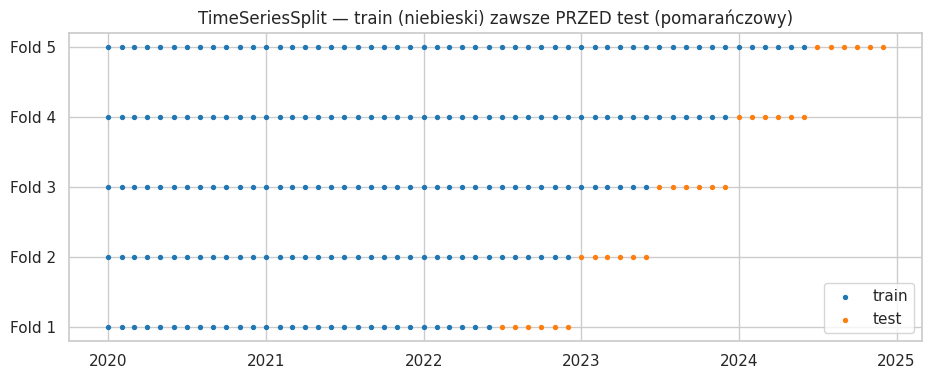

In [14]:
tscv = TimeSeriesSplit(n_splits=5, test_size=6)   # 5 foldów, każdy test = 6 miesięcy do przodu

fig, ax = plt.subplots(figsize=(11, 4))
for i, (idx_train, idx_test) in enumerate(tscv.split(sprzedaz)):
    ax.scatter(sprzedaz.index[idx_train], [i] * len(idx_train), c="tab:blue", s=8, label="train" if i == 0 else None)
    ax.scatter(sprzedaz.index[idx_test], [i] * len(idx_test), c="tab:orange", s=8, label="test" if i == 0 else None)
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.legend()
ax.set_title("TimeSeriesSplit — train (niebieski) zawsze PRZED test (pomarańczowy)")
plt.show()

Zwróć uwagę: `TimeSeriesSplit` **nie ma parametru `shuffle`** — to nie
przeoczenie w API, to świadome ograniczenie, bo dla szeregów czasowych
tasowanie nigdy nie jest poprawną opcją.

## 8. Podejście feature-based — lagi + model ML

Alternatywa dla ARIMA: przekształć szereg czasowy w zwykły problem
regresji tabelarycznej (cechy → target), potem użyj dowolnego modelu z
notebooka o sklearn. Wymaga cech opóźnionych (lag) i kalendarzowych —
dokładnie to, co budowaliśmy w notebooku o feature engineering
(kodowanie cykliczne miesiąca!).

In [15]:
df_features = pd.DataFrame({"sprzedaz": sprzedaz})

# cechy opóźnione (lag) — sprzedaż sprzed 1, 2, 3 i 12 miesięcy
for lag in [1, 2, 3, 12]:
    df_features[f"lag_{lag}"] = df_features["sprzedaz"].shift(lag)

# cechy z ruchomego okna — TYLKO na podstawie danych DO bieżącego punktu (shift(1) przed rolling!)
df_features["rolling_mean_3"] = df_features["sprzedaz"].shift(1).rolling(3).mean()
df_features["rolling_std_3"] = df_features["sprzedaz"].shift(1).rolling(3).std()

# cechy kalendarzowe (jak w notebooku o feature engineering)
df_features["miesiac_sin"] = np.sin(2 * np.pi * df_features.index.month / 12)
df_features["miesiac_cos"] = np.cos(2 * np.pi * df_features.index.month / 12)

df_features = df_features.dropna()   # pierwsze 12 wierszy nie ma pełnego kompletu lagów -> odrzucamy
df_features.head()

,sprzedaz,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3,miesiac_sin,miesiac_cos
2021-01-01,993.468626,1095.820058,1015.152018,970.851263,845.077944,1027.274446,63.360200,0.500000,8.660254e-01
2021-02-01,1143.905659,993.468626,1095.820058,1015.152018,851.160276,1034.813567,53.934093,0.866025,5.000000e-01
2021-03-01,1217.881069,1143.905659,993.468626,1095.820058,1072.145716,1077.731448,76.832439,1.000000,6.123234e-17
2021-04-01,1251.832283,1217.881069,1143.905659,993.468626,1197.111849,1118.418451,114.356611,0.866025,-5.000000e-01
2021-05-01,1412.279280,1251.832283,1217.881069,1143.905659,1110.380258,1204.539670,55.186355,0.500000,-8.660254e-01


**Krytyczna pułapka przy `rolling`:** `rolling(3).mean()` liczone
BEZPOŚREDNIO na `df_features["sprzedaz"]` (bez `.shift(1)` przed nim)
włącza do średniej **wartość z bieżącego wiersza** — czyli cechę
zbudowaną częściowo z targetu, którego model ma dopiero się nauczyć
przewidzieć. To dokładnie ten sam mechanizm leakage co target encoding bez
K-Fold w notebooku o feature engineering, tylko w przebraniu "okna
ruchomego". `.shift(1)` PRZED `.rolling()` gwarantuje, że okno kończy się
na poprzednim punkcie, nigdy na bieżącym.

In [16]:
X = df_features.drop(columns=["sprzedaz"])
y = df_features["sprzedaz"]

# walidacja krocząca (sekcja 7) na modelu ML — te same zasady, inny model
tscv_features = TimeSeriesSplit(n_splits=4)
wyniki_mae = []

for idx_train, idx_test in tscv_features.split(X):
    X_tr, X_te = X.iloc[idx_train], X.iloc[idx_test]
    y_tr, y_te = y.iloc[idx_train], y.iloc[idx_test]

    model_rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    model_rf.fit(X_tr, y_tr)
    predykcje = model_rf.predict(X_te)
    wyniki_mae.append(mean_absolute_error(y_te, predykcje))

print(f"MAE w kolejnych foldach: {np.round(wyniki_mae, 1)}")
print(f"Średnie MAE: {np.mean(wyniki_mae):.1f}")

MAE w kolejnych foldach: [137.4  68.3  33.6  96.9]
Średnie MAE: 84.0


## 9. Metryki oceny prognoz — który wybrać

| Metryka | Wzór (idea) | Kiedy używać | Uwaga |
|---|---|---|---|
| **MAE** | średni \|błąd\| | domyślny, dobrze interpretowalny wybór | w tych samych jednostkach co dane (np. PLN) |
| **RMSE** | pierwiastek ze średniego błędu² | gdy duże błędy mają być karane mocniej | wrażliwy na outliery |
| **MAPE** | średni \|błąd\|/rzeczywista, w % | porównania między szeregami o różnej skali | **zawodzi przy wartościach bliskich zeru** (dzielenie przez ~0) |
| **MASE** | MAE modelu / MAE baseline'u naiwnego | porównanie z baseline w jednej liczbie | wartość < 1 = model bije baseline |

In [17]:
def mape(y_prawdziwe, y_prognoza):
    return np.mean(np.abs((y_prawdziwe - y_prognoza) / y_prawdziwe)) * 100

mase = mae_sarima / mae_naiwny   # MASE: SARIMA vs baseline naiwny z sekcji 5

print(f"MAE:  {mae_sarima:.1f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test, wartosci_prognozy)):.1f}")
print(f"MAPE: {mape(test.values, wartosci_prognozy.values):.1f}%")
print(f"MASE: {mase:.3f}  ({'model bije baseline' if mase < 1 else 'baseline nadal lepszy!'})")

MAE:  50.5
RMSE: 62.0
MAPE: 2.9%
MASE: 0.321  (model bije baseline)


## Podsumowanie

1. **Regularny indeks czasowy** (`resample` do stałej częstotliwości) to
   fundament — bez tego żaden model z tego notebooka nie zadziała poprawnie.
2. **Dekompozycja + ADF** przed wyborem modelu — sprawdź, czy jest trend,
   sezonowość, i czy szereg jest stacjonarny, zamiast zgadywać.
3. **Zawsze baseline** (naiwna prognoza sezonowa) — złożony model bez tego
   punktu odniesienia nie ma uzasadnienia biznesowego.
4. **`TimeSeriesSplit`, nigdy losowy split/k-fold** — to najważniejsza
   lekcja notebooka. Dotyczy zarówno ARIMA/SARIMA, jak i podejścia
   feature-based z dowolnym modelem sklearn.
5. **`.shift(1)` przed `.rolling()`** przy budowie cech — inaczej leakage
   przez okno ruchome zawierające bieżącą wartość.
6. **Przedział ufności, nie tylko prognoza punktowa** — niepewność rośnie
   z horyzontem prognozy, i to jest informacja, nie usterka.
7. **MASE** jako pojedyncza liczba odpowiadająca wprost na pytanie "czy w
   ogóle warto było budować model" (< 1 = tak, bije naiwny baseline).